In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pandas

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

In [6]:
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [7]:
!unzip images.zip

Archive:  images.zip
  inflating: images/.DS_Store        
   creating: images/dent/
 extracting: images/dent/dent_001.png  
 extracting: images/dent/dent_002.png  
 extracting: images/dent/dent_003.png  
 extracting: images/dent/dent_004.png  
 extracting: images/dent/dent_005.png  
 extracting: images/dent/dent_006.png  
 extracting: images/dent/dent_007.png  
 extracting: images/dent/dent_008.png  
 extracting: images/dent/dent_009.png  
 extracting: images/dent/dent_010.png  
 extracting: images/dent/dent_011.png  
 extracting: images/dent/dent_012.png  
 extracting: images/dent/dent_013.png  
 extracting: images/dent/dent_014.png  
 extracting: images/dent/dent_015.png  
 extracting: images/dent/dent_016.png  
 extracting: images/dent/dent_017.png  
 extracting: images/dent/dent_018.png  
 extracting: images/dent/dent_019.png  
 extracting: images/dent/dent_020.png  
 extracting: images/dent/dent_021.png  
 extracting: images/dent/dent_022.png  
 extracting: images/dent/dent_023.p

In [11]:
dataset_path = "/content/images"

In [12]:
classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['normal', '.DS_Store', 'scratch', 'dent', 'stain']


In [13]:
print("Number of Classes:", len(classes))

Number of Classes: 5


In [15]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(dataset_path))} images")

normal: 5 images
.DS_Store: 5 images
scratch: 5 images
dent: 5 images
stain: 5 images


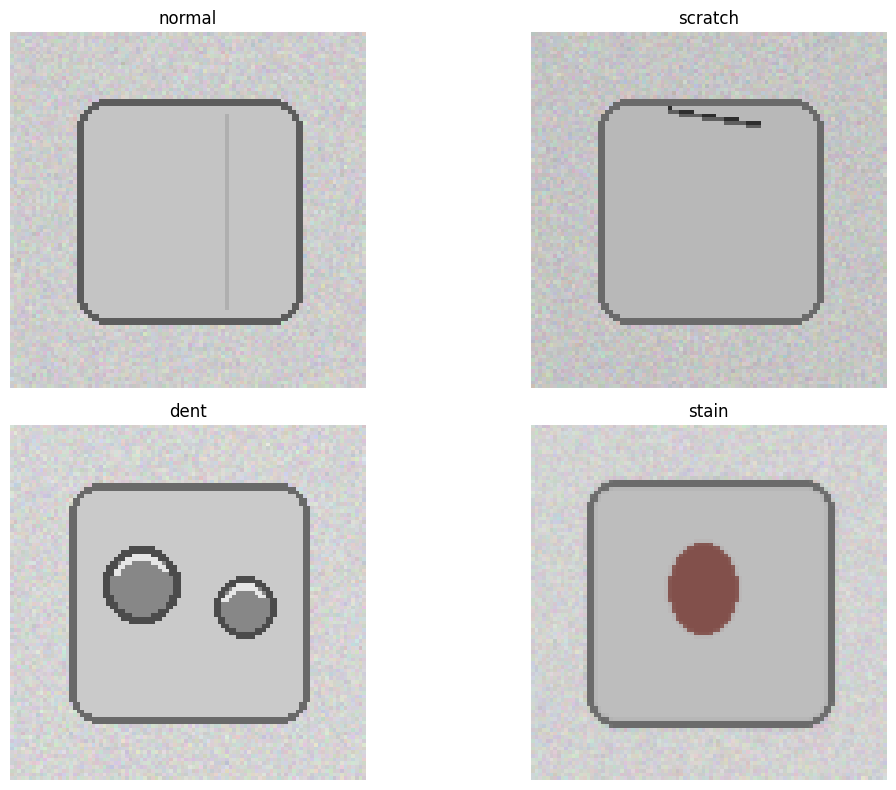

In [20]:
plt.figure(figsize=(12,8))
classes = [cls for cls in os.listdir(dataset_path) if not cls.startswith('.')]

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_file = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, image_file)

    img = plt.imread(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.tight_layout()

plt.show()

In [21]:
sample_image = plt.imread(img_path)

print("Image Shape:", sample_image.shape)

Image Shape: (96, 96, 3)


In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

In [23]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [24]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


In [25]:
model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2161 - loss: 1.5788 - val_accuracy: 0.2500 - val_loss: 1.3859
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2943 - loss: 1.3872 - val_accuracy: 0.2812 - val_loss: 1.3783
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3776 - loss: 1.3260 - val_accuracy: 0.4896 - val_loss: 1.2059
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5312 - loss: 1.0648 - val_accuracy: 0.6667 - val_loss: 0.8617
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6745 - loss: 0.7874 - val_accuracy: 0.8333 - val_loss: 0.6224
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7266 - loss: 0.6433 - val_accuracy: 0.6771 - val_loss: 0.6344
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7240 - loss: 0.6390 - val_accuracy: 0.7917 - val_loss: 0.5014
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7969 - loss: 0.5057 - val_accuracy: 0.8854 - val_loss:

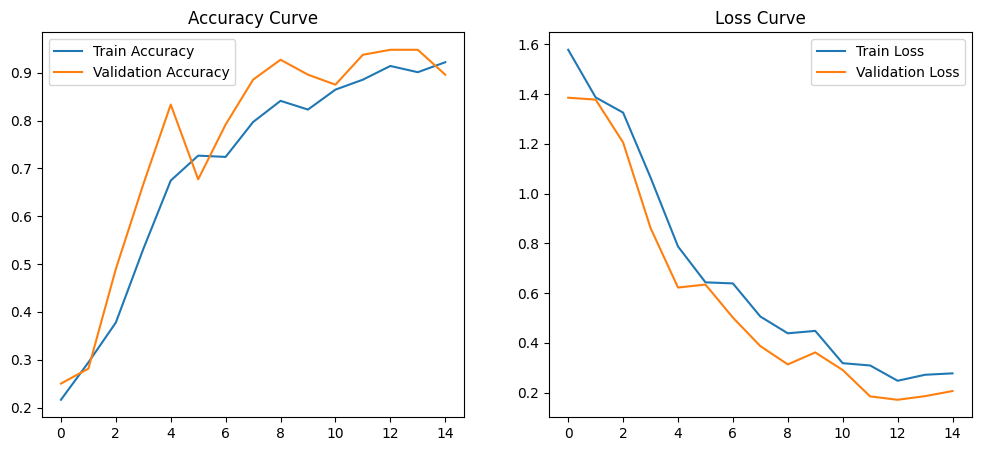

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.savefig("accuracy_loss_curves.png")

plt.show()

In [30]:
predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step


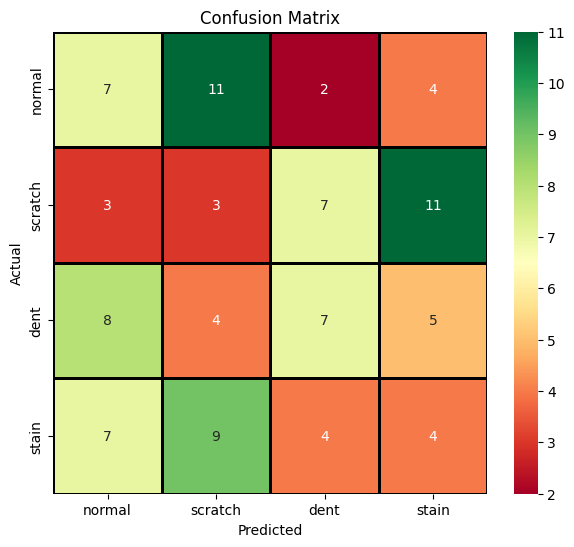

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    xticklabels=classes,
    yticklabels=classes,
    linewidths=1,
    linecolor='black'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [32]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

      normal       0.28      0.29      0.29        24
     scratch       0.11      0.12      0.12        24
        dent       0.35      0.29      0.32        24
       stain       0.17      0.17      0.17        24

    accuracy                           0.22        96
   macro avg       0.23      0.22      0.22        96
weighted avg       0.23      0.22      0.22        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step


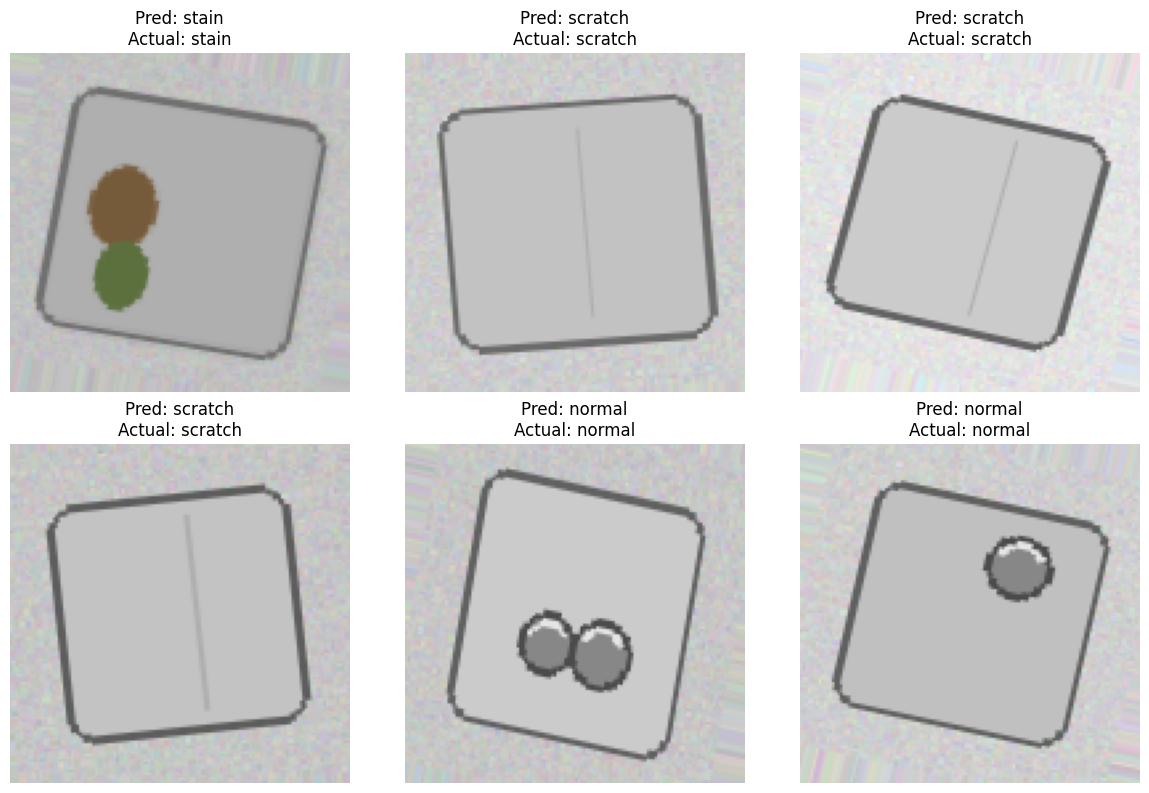

In [33]:
plt.figure(figsize=(12,8))

images, labels = next(validation_generator)

preds = model.predict(images)

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    pred_label = classes[np.argmax(preds[i])]

    true_label = classes[np.argmax(labels[i])]

    plt.title(f"Pred: {pred_label}\nActual: {true_label}")

    plt.axis('off')

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()